In [1]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison

## Analysis of Larger experiments


In [2]:
bpr_unbiased_calibrated_time = "experiments/yelp/bpr_unbiased_calibrated_time_based_large.yaml"
bpr_unbiased_calibrated_steck = "experiments/yelp/bpr_unbiased_calibrated_constant_large.yaml"

bpr_debiased = "experiments/yelp/bpr_unbiased_uncalibrated_large.yaml"

random_rec = "experiments/yelp/random_rec_uncalibrated_large.yaml"
most_popular = "experiments/yelp/most_popular_uncalibrated_large.yaml"

### Taste distortion between recommendation and initial state


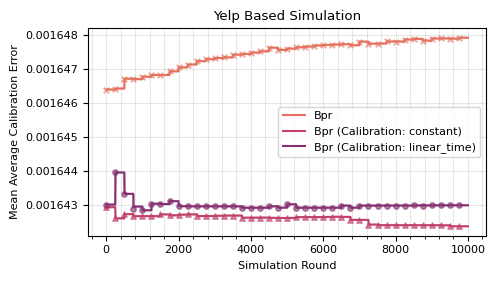

In [3]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="mace", title="Yelp Based Simulation", graph="line", plot_retrain_points=True,  window_size=5, should_remove_outliers=False)

We see a similar behaviour in terms of MACE for yelp, with time based calibration performing slightly worse than constant calibration. We also see that uncalibrated BPR MACE changes over time, increasing over time, contrary to movielens. This difference might be dataset related, but we leave further investigation to future work.

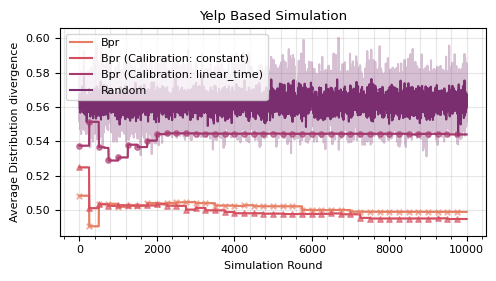

In [4]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time, random_rec], metric_name="diver", title="Yelp Based Simulation", graph="line", plot_retrain_points=True,  window_size=5)

On the other hand, We see that miscalibration is considerably worse for time based calibration. This is interesting because the yelp bootstrapped set has a larger average timestamp between consecutive interactions than movielens, so the expected behavior would be a similar performance in terms of miscalibration. In fact, the initial performance is relatively similar. But as the simulation goes on and model retrains happen, The linear time variant remains as the worst variant, whereas constant calibration and uncalibrated variants remain similar.

This suggests a struggle in time based calibration applied to datasets with a higher time horizon. The large difference in values of calibration between both datasets also suggests that calibration is harder on this dataset, possibly due to the larger numer of genres in it (20 x 230). Further research is needed to validate this point.

### Analisando diversidade



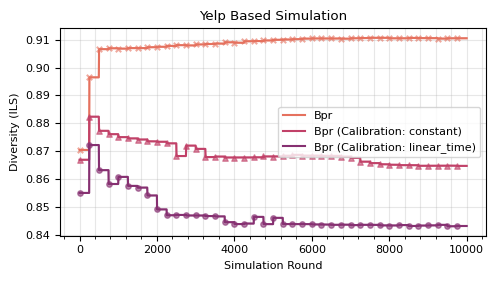

In [5]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="div", title="Yelp Based Simulation", graph="line", plot_retrain_points=True,  window_size=5)



Finally, on diversity, we see a consistent performance between constant and linear time calibration resulting in less diverse recommendations, with this diversity diminishing over time. This is consistent with findings on calibration diminishing diversity over time in the static scenario.

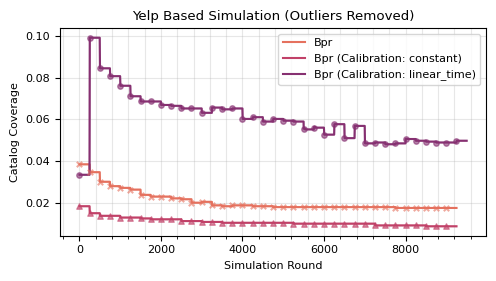

In [6]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="coverage", title="Yelp Based Simulation", graph="line", plot_retrain_points=True,  window_size=5, should_remove_outliers=True)

We see a consistent behavior in terms of catalog coverage here in comparison to movielens: Its interesting to note that again linear time calibration achieves a higher level of catalog coverage, although every variant shows that recommendations get more and more concentrated through time.

Our findings suggests that calibration might introduce a narrowing effect on recommendations through time. This is specially strong for yelp, where we see that coverage goes down through time as does  diversity in recommendations

Interestingly enough, this evolving effect is less pronounced on movielens based experiment.  Notice that after around 3 or 4 retraining rounds (therefore, around simuulation 750), the evolution effect stabilizes on movielens. This might be an effect of the density of the datasets: as the catalog in movielens is smaller, the ammount of items to be exposed is smaller, so the ammount of possible preferences expressed through time might be smaller 

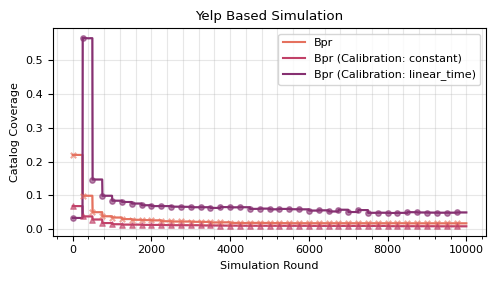

In [7]:
plot_metric_comparison([bpr_debiased, bpr_unbiased_calibrated_steck, bpr_unbiased_calibrated_time], metric_name="coverage", title="Yelp Based Simulation", graph="line", plot_retrain_points=True,  window_size=5, should_remove_outliers=False)